# Nexus-Steg: Training Notebook

**Robust Semantic-Texture Hybrid Steganography System**

Assumes dataset is already on Drive. Runs: sanity check, overfit test, full training, evaluation.

**Runtime:** GPU (A100 recommended). Go to Runtime > Change runtime type > A100.

## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Update Drive Repo → Clone to Local → Install

In [3]:
import os, shutil

DRIVE_DIR = "/content/drive/MyDrive/DL_Project/Nexus-Steg"
PROJECT_DIR = "/content/Nexus-Steg"
REPO_URL = "https://github.com/Henildiyora/Nexus-Steg.git"
BRANCH = "improvement/mod_training_pipeline"

# --- Step 1: Update the Drive repo ---
if os.path.exists(DRIVE_DIR):
    print(">>> Pulling latest changes in Drive repo …")
    %cd "$DRIVE_DIR"
    !git pull origin $BRANCH
else:
    print(f"Drive repo not found at {DRIVE_DIR}, skipping pull.")

# --- Step 2: Fresh clone into /content/ (local disk = faster I/O) ---
if os.path.exists(PROJECT_DIR):
    print(f">>> Removing old local clone at {PROJECT_DIR} …")
    shutil.rmtree(PROJECT_DIR)

print(">>> Cloning repo into /content/ …")
!git clone -b $BRANCH $REPO_URL "$PROJECT_DIR"

# --- Step 3: Install ---
%cd "$PROJECT_DIR"
!pip install -e . -q
print("\nRepo ready at:", PROJECT_DIR)

>>> Pulling latest changes in Drive repo …
/content/drive/MyDrive/DL_Project/Nexus-Steg
From https://github.com/Henildiyora/Nexus-Steg
 * branch            improvement/mod_training_pipeline -> FETCH_HEAD
Already up to date.
>>> Cloning repo into /content/ …
Cloning into '/content/Nexus-Steg'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 166 (delta 84), reused 128 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 5.60 MiB | 12.54 MiB/s, done.
Resolving deltas: 100% (84/84), done.


## 3a. Download Cover Images (MS-COCO val2017 + test2017, ~7 GB)

In [4]:
import os, glob

%cd "$PROJECT_DIR"

COVER_DIR = os.path.join(PROJECT_DIR, "datasets", "cover")
os.makedirs(COVER_DIR, exist_ok=True)
existing_cover = len(glob.glob(os.path.join(COVER_DIR, "*")))

if existing_cover >= 40_000:
    print(f"Cover images already present ({existing_cover} files) — skipping.")
else:
    print(">>> Downloading MS-COCO val2017 (~1 GB) …")
    !curl -L --progress-bar -o datasets/val2017.zip "http://images.cocodataset.org/zips/val2017.zip"
    !unzip -q -o datasets/val2017.zip -d datasets/
    !mv datasets/val2017/* "$COVER_DIR/"
    !rm -rf datasets/val2017 datasets/val2017.zip

    print(">>> Downloading MS-COCO test2017 (~6 GB) …")
    !curl -L --progress-bar -o datasets/test2017.zip "http://images.cocodataset.org/zips/test2017.zip"
    !unzip -q -o datasets/test2017.zip -d datasets/
    !mv datasets/test2017/* "$COVER_DIR/"
    !rm -rf datasets/test2017 datasets/test2017.zip

print(f"Cover images: {len(glob.glob(os.path.join(COVER_DIR, '*')))} files")

/content/Nexus-Steg
>>> Downloading MS-COCO val2017 (~1 GB) …
######################################################################## 100.0%
>>> Downloading MS-COCO test2017 (~6 GB) …
######################################################################## 100.0%
Cover images: 45670 files


## 3b. Download Secret Images (SpaceNet 2 MUL-PanSharpen, 4 cities, ~8 GB)

In [5]:
import os, glob

%cd "$PROJECT_DIR"

SECRET_DIR = os.path.join(PROJECT_DIR, "datasets", "secret", "MUL-PanSharpen")
os.makedirs(SECRET_DIR, exist_ok=True)
existing_secret = len(glob.glob(os.path.join(SECRET_DIR, "*.tif")))

if existing_secret >= 100:
    print(f"Secret images already present ({existing_secret} files) — skipping.")
else:
    print(">>> Installing AWS CLI …")
    !pip install awscli -q

    S3_BUCKET = "s3://spacenet-dataset/spacenet/SN2_buildings"
    CITIES = ["AOI_2_Vegas", "AOI_3_Paris", "AOI_4_Shanghai", "AOI_5_Khartoum"]

    for city in CITIES:
        for s3_split in ["train", "test_public"]:
            s3_path = f"{S3_BUCKET}/{s3_split}/{city}/PS-MS/"
            print(f">>> Downloading {city} ({s3_split}) …")
            !aws s3 cp "$s3_path" "$SECRET_DIR/" --recursive --no-sign-request --quiet

print(f"Secret images: {len(glob.glob(os.path.join(SECRET_DIR, '*.tif')))} files")

/content/Nexus-Steg
>>> Installing AWS CLI …
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 144.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 12.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
>>> Downloading AOI_2_Vegas (train) …
>>> Downloading AOI_2_Vegas (test_public) …
>>> Downloading AOI_3_Paris (train) …
>>> Downloading AOI_3_Paris (test_public) …
>>> Downloading AOI_4_Shanghai (train) …
>>> Downloading AOI_4_Shanghai (test_public) …
>>> Downloading AOI_5_Khartoum (train) …
>>> Downloading AOI_5_Khartoum (test_public) …
Secret images: 14119 files


## 4. Verify Dataset

/content/Nexus-Steg
Cover images:  45670
Secret images: 14119
Training pairs (min): 14119


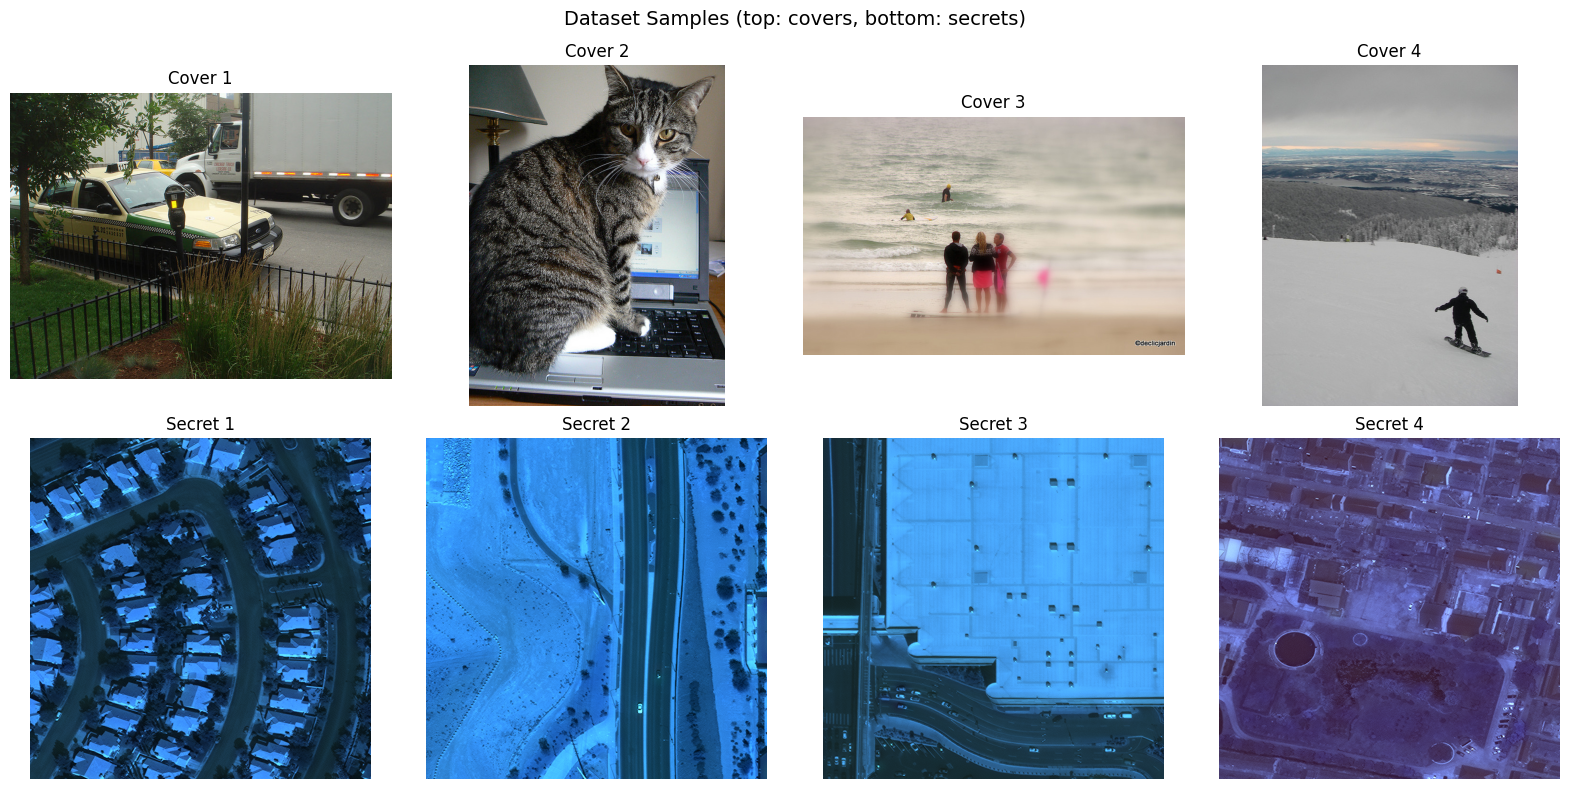

In [6]:
import os, glob
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

%cd "$PROJECT_DIR"

cover_files = sorted(glob.glob("datasets/cover/*.[jp][pn][g]*"))
secret_files = sorted(glob.glob("datasets/secret/MUL-PanSharpen/*.tif"))

print(f"Cover images:  {len(cover_files)}")
print(f"Secret images: {len(secret_files)}")
print(f"Training pairs (min): {min(len(cover_files), len(secret_files))}")

assert len(cover_files) > 0, "No cover images found!"
assert len(secret_files) > 0, "No secret images found!"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Dataset Samples (top: covers, bottom: secrets)", fontsize=14)

for i in range(4):
    img = Image.open(cover_files[i * len(cover_files) // 4]).convert("RGB")
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Cover {i+1}")
    axes[0, i].axis("off")

import tifffile as tiff
for i in range(4):
    raw = tiff.imread(secret_files[i * len(secret_files) // 4])
    if raw.dtype == np.uint16:
        p2, p98 = np.percentile(raw, (2, 98))
        raw = np.clip(raw, p2, p98)
        raw = ((raw - p2) / max(p98 - p2, 1e-6) * 255).astype(np.uint8)
    if len(raw.shape) == 3:
        if raw.shape[0] < raw.shape[2]:
            raw = raw.transpose(1, 2, 0)
        raw = raw[:, :, :3]
    axes[1, i].imshow(raw)
    axes[1, i].set_title(f"Secret {i+1}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 5. Sanity Check

| Loss | Expected | If Wrong |
|------|----------|----------|
| `l_inv` | 0.01 - 0.10 | Encoder init problem |
| `l_rec` | 0.30 - 0.70 | Reveal network problem |
| `l_disc` | ~0.693 | Discriminator init problem |

In [7]:
%cd "$PROJECT_DIR"
!python main.py --sanity --num_workers 12

/content/Nexus-Steg
CUDA is available. Using GPU.
CUDA is available. Using GPU.
Cover path: /content/Nexus-Steg/datasets/cover | Found: 45670 images
Secret path: /content/Nexus-Steg/datasets/secret/MUL-PanSharpen | Found: 14119 images
Dataset split: 11296 train / 2823 val  (12 workers)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:02<00:00, 231MB/s]
  SANITY CHECK
  Saved 8 cover + 8 secret images to results/sanity_inputs.png
  Cover range: [-1.000, 1.000]
  Secret range: [-1.000, 1.000]

  Initial losses (before any training):
    l_inv  = 0.0010  (expected: small, ~0.01-0.10)
    l_rec  = 0.2823  (expected: ~0.30-0.70)
    l_disc = 0.6485  (expected: ~0.693 = log(2))
  All initial losses look reasonable.


## 6. Overfit One Batch

- **PASS** (loss < 0.01): Model capacity is sufficient.
- **WARN** (loss 0.01-0.10): Probably fine, monitor during training.
- **FAIL** (loss > 0.10): Architecture or LR problem.

In [8]:
%cd "$PROJECT_DIR"
!python main.py --overfit_one_batch --num_workers 12

/content/Nexus-Steg
CUDA is available. Using GPU.
CUDA is available. Using GPU.
Cover path: /content/Nexus-Steg/datasets/cover | Found: 45670 images
Secret path: /content/Nexus-Steg/datasets/secret/MUL-PanSharpen | Found: 14119 images
Dataset split: 11296 train / 2823 val  (12 workers)
  OVERFIT ONE BATCH (Karpathy Recipe 2.8)
  Training on 1 batch for 200 steps...
  Step   0/200 | loss=2.104489  inv=0.382846  rec=0.344329  disc=0.6948
  Step  10/200 | loss=1.397660  inv=0.380195  rec=0.203493  disc=0.6931
  Step  20/200 | loss=1.047083  inv=0.376542  rec=0.134108  disc=0.6931
  Step  30/200 | loss=0.800798  inv=0.373159  rec=0.085528  disc=0.6929
  Step  40/200 | loss=0.724130  inv=0.369811  rec=0.070864  disc=0.6926
  Step  50/200 | loss=0.671499  inv=0.366404  rec=0.061019  disc=0.6933
  Step  60/200 | loss=0.644772  inv=0.363009  rec=0.056353  disc=0.6894
  Step  70/200 | loss=0.620913  inv=0.359651  rec=0.052252  disc=0.6829
  Step  80/200 | loss=0.614432  inv=0.356702  rec=0.0515

## 7. Train

| Phase | Epochs | What Happens |
|-------|--------|-------------|
| 1 | 0-29 | Pure hiding/recovery (rec_w=10). No noise, no adversarial. |
| 2 | 30-59 | Noise layer ON, adversarial ON (rec_w=20, adv_w=0.05). |
| 3 | 60+ | Full adversarial pressure (rec_w=30, adv_w=0.1). |

Recovery loss now includes MSE + SSIM + perceptual. Discriminator trains every 2 steps with label smoothing.

Early stopping after 15 epochs without improvement. Best checkpoint saved to `checkpoints/nexus_best.pth`.

In [7]:
%cd "$PROJECT_DIR"
!python main.py --epochs 150 --batch_size 96 --checkpoint_every 10 --patience 15 --num_workers 12

/content/Nexus-Steg
CUDA is available. Using GPU.
CUDA is available. Using GPU.
Cover path: /content/Nexus-Steg/datasets/cover | Found: 45670 images
Secret path: /content/Nexus-Steg/datasets/secret/MUL-PanSharpen | Found: 14119 images
Dataset split: 11296 train / 2823 val  (12 workers)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:02<00:00, 226MB/s]
Starting Nexus-Steg Training on cuda
Epoch 0/150 (Phase 1): 100% 118/118 [04:44<00:00,  2.41s/it, disc=0.6856, inv=0.3524, loss=1.8169, rec=0.1464]
  Val | PSNR(stego): 32.04dB  SSIM(stego): 0.9069  PSNR(secret): 15.33dB  SSIM(secret): 0.2946
Epoch 1/150 (Phase 1): 100% 118/118 [02:54<00:00,  1.48s/it, disc=0.6065, inv=0.3317, loss=1.3128, rec=0.0981]
  Val | PSNR(stego): 32.05dB  SSIM(stego): 0.9079  PSNR(secret): 16.15dB  SSIM(secret): 0.3218
Epoch 2/150 (Phase 1): 100% 118/118 [02:53<00:00,  1.47s/it, disc=0.6059, inv=0.3142, loss=1.1177, 

## 8. Plot Training Curves

/content/Nexus-Steg


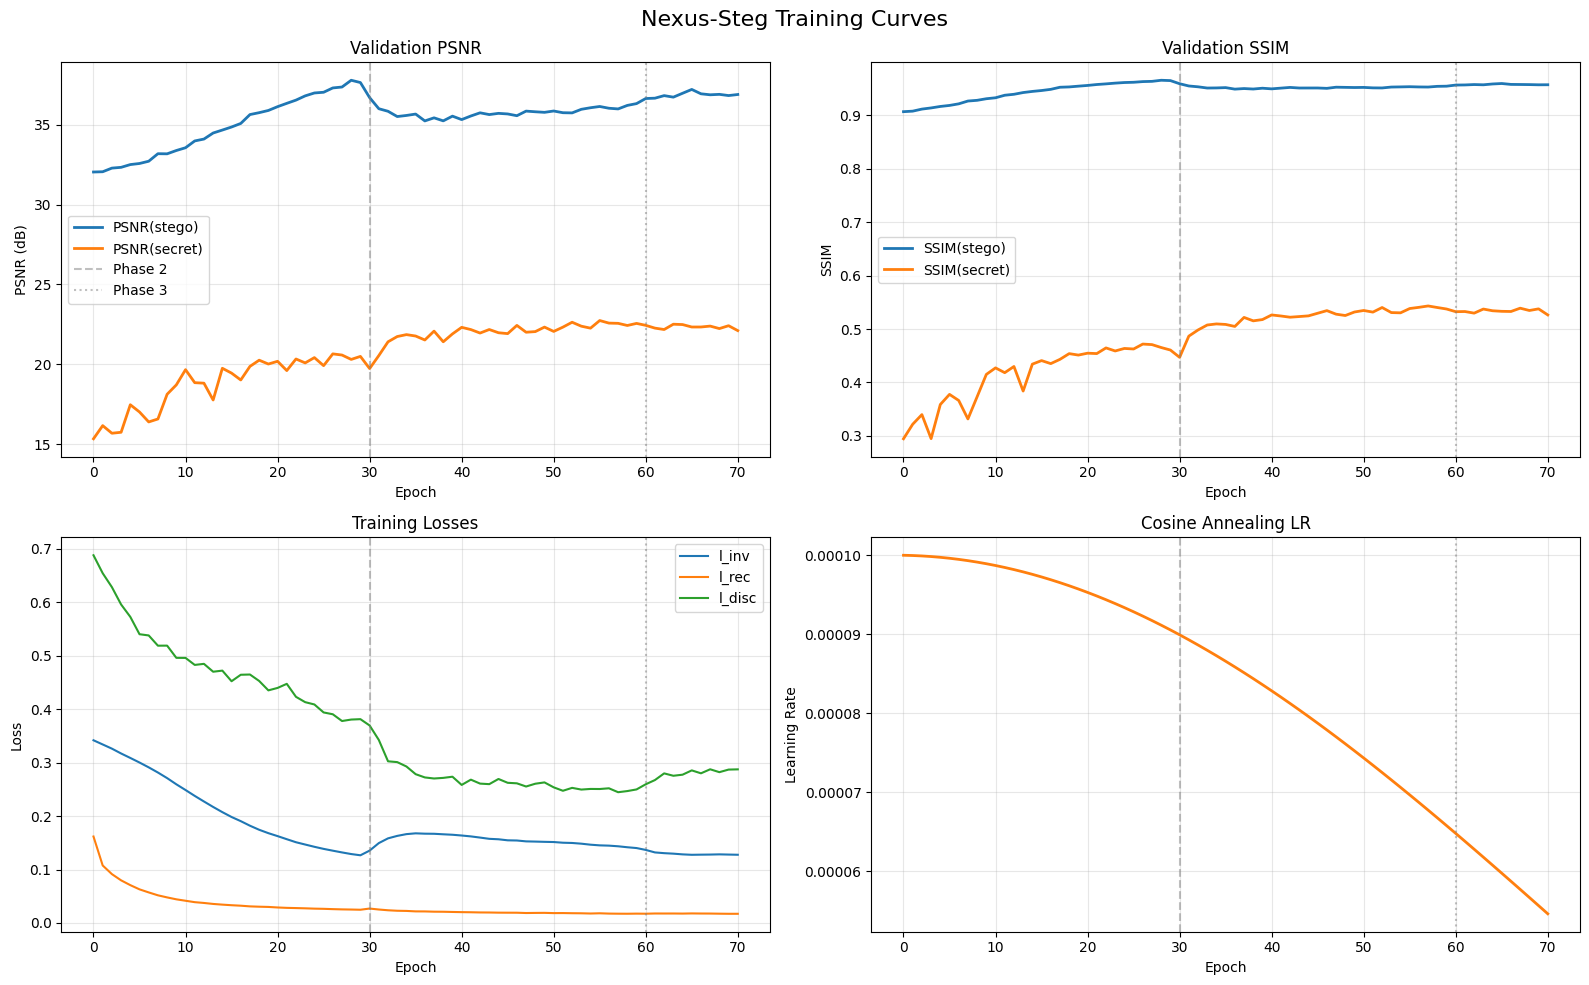

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

%cd "$PROJECT_DIR"
df = pd.read_csv("results/training_log.csv")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Nexus-Steg Training Curves", fontsize=16)

ax = axes[0, 0]
ax.plot(df["epoch"], df["val_psnr_stego"], label="PSNR(stego)", linewidth=2)
ax.plot(df["epoch"], df["val_psnr_secret"], label="PSNR(secret)", linewidth=2)
ax.axvline(x=30, color="gray", linestyle="--", alpha=0.5, label="Phase 2")
ax.axvline(x=60, color="gray", linestyle=":", alpha=0.5, label="Phase 3")
ax.set_xlabel("Epoch"); ax.set_ylabel("PSNR (dB)")
ax.set_title("Validation PSNR"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(df["epoch"], df["val_ssim_stego"], label="SSIM(stego)", linewidth=2)
ax.plot(df["epoch"], df["val_ssim_secret"], label="SSIM(secret)", linewidth=2)
ax.axvline(x=30, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=60, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("SSIM")
ax.set_title("Validation SSIM"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(df["epoch"], df["l_inv"], label="l_inv", linewidth=1.5)
ax.plot(df["epoch"], df["l_rec"], label="l_rec", linewidth=1.5)
ax.plot(df["epoch"], df["l_disc"], label="l_disc", linewidth=1.5)
ax.axvline(x=30, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=60, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Losses"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(df["epoch"], df["lr"], linewidth=2, color="tab:orange")
ax.axvline(x=30, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=60, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning Rate")
ax.set_title("Cosine Annealing LR"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=150)
plt.show()

## 9. Evaluate

Runs 8 attack tests: Basic Recovery, JPEG-90, JPEG-50, Blur, Noise, Screenshot, Social Media, Steganalysis.

In [9]:
%cd "$PROJECT_DIR"
!python evaluate.py --checkpoint checkpoints/nexus_best.pth

/content/Nexus-Steg
CUDA is available. Using GPU.
Loaded checkpoint: checkpoints/nexus_best.pth  (epoch 55)
Learned alpha (residual scale): 0.1607
CUDA is available. Using GPU.
Cover path: /content/Nexus-Steg/datasets/cover | Found: 45670 images
Secret path: /content/Nexus-Steg/datasets/secret/MUL-PanSharpen | Found: 14119 images
Dataset split: 11296 train / 2823 val  (8 workers)
       NEXUS-STEG EVALUATION REPORT

  TEST: Basic Recovery (no attack)
    PSNR(stego vs cover):  37.77 dB  [PASS > 30dB]
    SSIM(stego vs cover):  0.9513     [PASS > 0.90]
    PSNR(secret recover):  24.54 dB  [WARN > 28dB]
    SSIM(secret recover):  0.5456     [FAIL > 0.80]

  TEST: JPEG-90 Robustness
    Secret PSNR: 19.54 dB  [WARN > 22dB]
    Secret SSIM: 0.3917    [FAIL > 0.5]

  TEST: JPEG-50 Robustness (heavy)
    Secret PSNR: 16.87 dB  [WARN > 18dB]
    Secret SSIM: 0.2784    [FAIL > 0.35]

  TEST: Gaussian Blur (sigma=2.0)
    Secret PSNR: 20.16 dB  [PASS > 18dB]
    Secret SSIM: 0.4452    [PASS > 0

## 10. Display Visual Results

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob, os

%cd "$PROJECT_DIR"

epoch_imgs = []
for target in [0, 29, 59, 99]:
    path = f"results/epoch_{target}.png"
    if os.path.exists(path):
        epoch_imgs.append((target, path))

if not epoch_imgs:
    all_epochs = sorted(glob.glob("results/epoch_*.png"))
    for p in all_epochs[:4]:
        e = int(os.path.basename(p).split("_")[1].split(".")[0])
        epoch_imgs.append((e, p))

if epoch_imgs:
    fig, axes = plt.subplots(len(epoch_imgs), 1, figsize=(20, 5 * len(epoch_imgs)))
    if len(epoch_imgs) == 1:
        axes = [axes]
    for ax, (e, path) in zip(axes, epoch_imgs):
        ax.imshow(mpimg.imread(path))
        ax.set_title(f"Epoch {e}  [cover | secret | stego | revealed]", fontsize=13)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No epoch images found yet.")

print("\n--- Evaluation Attack Results ---\n")
eval_imgs = sorted(glob.glob("results/evaluation/*.png"))
if eval_imgs:
    fig, axes = plt.subplots(len(eval_imgs), 1, figsize=(20, 4 * len(eval_imgs)))
    if len(eval_imgs) == 1:
        axes = [axes]
    for ax, path in zip(axes, eval_imgs):
        ax.imshow(mpimg.imread(path))
        ax.set_title(os.path.splitext(os.path.basename(path))[0].replace("_", " ").title(), fontsize=12)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation images found. Run Cell 8 first.")

Output hidden; open in https://colab.research.google.com to view.

## 11. Evaluation Report

In [11]:
import os
%cd "$PROJECT_DIR"

report_path = "results/evaluation/report.txt"
if os.path.exists(report_path):
    with open(report_path) as f:
        print(f.read())
else:
    print("No evaluation report found. Run Cell 8 first.")

/content/Nexus-Steg
NEXUS-STEG EVALUATION REPORT

FAIL  | Basic Recovery                      | PSNR=24.54dB  SSIM=0.5456
WARN  | JPEG-90 Robustness                  | PSNR=19.54dB  SSIM=0.3917
WARN  | JPEG-50 Robustness (heavy)          | PSNR=16.87dB  SSIM=0.2784
PASS  | Gaussian Blur (sigma=2.0)           | PSNR=20.16dB  SSIM=0.4452
PASS  | Gaussian Noise (std=0.05)           | PSNR=23.90dB  SSIM=0.4935
PASS  | Screenshot Sim (resize 50%)         | PSNR=23.27dB  SSIM=0.5203
PASS  | Social Media (WhatsApp-like)        | PSNR=17.43dB  SSIM=0.3061
FAIL  | Steganalysis Detection              | PSNR=91.67dB  SSIM=0.0000

SUMMARY: 4/8 PASS | 2/8 WARN | 2/8 FAIL

